<h1 align="center">Machine Learning for Bioinformatics</h1>
<h3 align="center">Freie Universität Berlin</h3>
<hr style="border:2px solid gray">

### Import Python packages
---

In [65]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
from torch.utils.data import Dataset, DataLoader, random_split

torch.manual_seed(0)
np.random.seed(0)

---
# Assignment 1: PyTorch basics
---
PyTorch is a library for numeric computing with tensors. A tensor is similar to a NumPy array, but PyTorch tensors can also keep track of computations for automatic differentiation and can be moved to accelerators such as GPUs.

In this exercise we first use PyTorch as a tensor library. Later we use the same spam-classification data to introduce `torch.nn.Module`, `BCELoss`, and the standard PyTorch training loop.

Install Torch for Python if necessary. Instructions are available [here](https://pytorch.org/get-started/locally/).

## 1.1 Tensors

Tensors store numeric data. They have a shape, a data type, and a device. Most operations are vectorized: instead of looping over individual entries, we apply one operation to the whole tensor.

In [66]:
data = [[1, 2, 3], [4, 5, 6]]

x = torch.tensor(data, dtype=torch.float32)
print(x)
print(f"shape:  {x.shape}")
print(f"dtype:  {x.dtype}")
print(f"device: {x.device}")

tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape:  torch.Size([2, 3])
dtype:  torch.float32
device: cpu


In [67]:
print(f"first row:       {x[0]}")
print(f"second column:   {x[:, 1]}")
print(f"column sums:     {x.sum(dim=0)}")
print(f"row means:       {x.mean(dim=1)}")
print(f"elementwise x^2:\n{x ** 2}")

first row:       tensor([1., 2., 3.])
second column:   tensor([2., 5.])
column sums:     tensor([5., 7., 9.])
row means:       tensor([2., 5.])
elementwise x^2:
tensor([[ 1.,  4.,  9.],
        [16., 25., 36.]])


Matrix-vector products are useful for many machine-learning models. In the small example below, each row represents one message and each column represents whether one word occurs in the message. Multiplying this matrix with a vector of word weights produces one score per message.

In [68]:
word_occurrences = torch.tensor([
    [1, 0, 1],
    [0, 1, 1],
    [1, 1, 0],
], dtype=torch.float32)

word_weights = torch.tensor([0.8, -0.4, 1.2])
bias = torch.tensor(-0.3)

scores = word_occurrences @ word_weights + bias
print(scores)

tensor([1.7000, 0.5000, 0.1000])


## 1.2 NumPy and PyTorch

NumPy arrays can be converted to PyTorch tensors and back. This is useful when data loading is easier with NumPy, but the computation should happen in PyTorch.

In [69]:
np_array = np.array([[1, 2], [3, 4]], dtype=np.float32)
torch_tensor = torch.from_numpy(np_array)

print(torch_tensor)
print(torch_tensor.numpy())

tensor([[1., 2.],
        [3., 4.]])
[[1. 2.]
 [3. 4.]]


## 1.3 Automatic differentiation

If a tensor has `requires_grad=True`, PyTorch records operations involving that tensor. Calling `backward()` computes numeric gradients for the current input values.

In [70]:
x = torch.tensor(2.0, requires_grad=True)
loss = (x - 5) ** 2

loss.backward()

print(f"x:        {x.item():.2f}")
print(f"loss:     {loss.item():.2f}")
print(f"gradient: {x.grad.item():.2f}")

x:        2.00
loss:     9.00
gradient: -6.00


An optimizer uses gradients to update parameters. The example below minimizes the function $(x - 5)^2$ numerically.

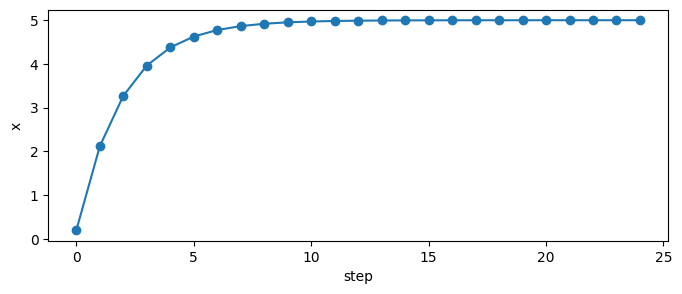

In [71]:
x = torch.tensor(-3.0, requires_grad=True)
optimizer = torch.optim.SGD([x], lr=0.2)

path = []
losses = []

for step in range(25):
    optimizer.zero_grad()
    loss = (x - 5) ** 2
    loss.backward()
    optimizer.step()

    path.append(x.item())
    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(path, marker="o")
plt.xlabel("step")
plt.ylabel("x")
plt.show()

---
# Assignment 2: SMS data as tensors
---
We now use the SMS spam data from the earlier spam-classification exercise. The model introduced earlier was Naive Bayes; here we first represent the same data as PyTorch tensors.

In [72]:
DATA_PATH = Path("exercise-data/SMSSpamCollection_cleaned.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("07-2-pytorch-intro/exercise-data/SMSSpamCollection_cleaned.csv")

sms_data = np.loadtxt(DATA_PATH, delimiter="\t", skiprows=1, dtype=str, encoding="utf-8")
labels = sms_data[:, 0]
messages = sms_data[:, 1]

y_np = (labels == "spam").astype(np.float32)

print(f"number of messages: {len(messages)}")
print(f"first label:        {labels[0]}")
print(f"first message:      {messages[0][:80]}...")

number of messages: 5572
first label:        ham
first message:      go until jurong point  crazy   available only in bugis n great world la e buffet...


## 2.1 Binary word-occurrence features

We build a vocabulary and encode each message as a binary vector. An entry is 1 if the word occurs in the message and 0 otherwise. To keep the feature matrix compact, we only keep words that occur at least five times.

In [73]:
def construct_vocabulary(messages, min_count=5):
    counter = Counter()
    for message in messages:
        counter.update(message.split())

    vocabulary = sorted(word for word, count in counter.items() if count >= min_count)
    return vocabulary, counter


def encode_messages(messages, vocabulary):
    word_to_index = {word: index for index, word in enumerate(vocabulary)}
    X = np.zeros((len(messages), len(vocabulary)), dtype=np.float32)

    for row, message in enumerate(messages):
        for word in set(message.split()):
            column = word_to_index.get(word)
            if column is not None:
                X[row, column] = 1.0

    return X


vocabulary, word_counter = construct_vocabulary(messages, min_count=5)
X_np = encode_messages(messages, vocabulary)

print(f"number of retained words: {len(vocabulary)}")
print(f"feature matrix shape:     {X_np.shape}")
print(f"10 most common words:     {word_counter.most_common(10)}")

number of retained words: 1893
feature matrix shape:     (5572, 1893)
10 most common words:     [('i', 3021), ('to', 2253), ('you', 2245), ('a', 1450), ('the', 1339), ('u', 1207), ('and', 980), ('in', 903), ('is', 897), ('me', 807)]


In [74]:
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).reshape(-1, 1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"spam prevalence: {y.mean().item():.3f}")

X shape: torch.Size([5572, 1893])
y shape: torch.Size([5572, 1])
spam prevalence: 0.134


Use tensor operations to answer the following questions:

1. How many ham and spam messages are in the dataset?
2. How many retained messages contain the words `free`, `win`, and `call`?

In [75]:
# Complete this cell.

num_spam = y.sum() # spams are encoded as 1
num_ham = y.shape[0] - num_spam # hams are encoded as 0
print(f"ham:  {num_ham}")
print(f"spam: {num_spam}")

for word in ["free", "win", "call"]:
    column = vocabulary.index(word) 
    print(word, sum(X[:, column]).item())

# Watch out: word_counter includes repetitions, while encoded messages only include presence/absence.
# see the ```for word in set(message.split()):```` part of the encode_messages function.
print("\n# total occurrences of the words (with repetitions):")
print("free:", word_counter["free"])
print("win:", word_counter["win"])
print("call:", word_counter["call"])


ham:  4825.0
spam: 747.0
free 229.0
win 70.0
call 550.0

# total occurrences of the words (with repetitions):
free: 284
win: 76
call: 593


## 2.2 Dataset and DataLoader

A `Dataset` stores examples and labels. A `DataLoader` creates mini-batches and can shuffle the examples during training.

In [76]:
class SMSDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    def num_features(self):
        return self.X.shape[1]


sms_dataset = SMSDataset(X, y)

# Use a validation set for threshold selection and model monitoring.
test_size = int(0.2 * len(sms_dataset))
validation_size = int(0.1 * len(sms_dataset))
train_size = len(sms_dataset) - validation_size - test_size

train_data, validation_data, test_data = random_split(
    sms_dataset,
    [train_size, validation_size, test_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

batch_X, batch_y = next(iter(train_loader))
print(f"batch X shape: {batch_X.shape}")
print(f"batch y shape: {batch_y.shape}")

batch X shape: torch.Size([128, 1893])
batch y shape: torch.Size([128, 1])


In [77]:
def subset_to_tensors(subset):
    loader = DataLoader(subset, batch_size=len(subset), shuffle=False)
    X_subset, y_subset = next(iter(loader))
    return X_subset, y_subset.reshape(-1)


X_train, y_train = subset_to_tensors(train_data)
X_val, y_val = subset_to_tensors(validation_data)
X_test, y_test = subset_to_tensors(test_data)

print(f"training examples:   {len(X_train)}")
print(f"validation examples: {len(X_val)}")
print(f"test examples:       {len(X_test)}")

training examples:   3901
validation examples: 557
test examples:       1114


In [78]:
def compute_confusion_matrix(y_true, y_pred):
    y_true = y_true.reshape(-1).to(torch.int64)
    y_pred = y_pred.reshape(-1).to(torch.int64)
    cm = torch.zeros((2, 2), dtype=torch.int64)

    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label, pred_label] += 1

    return cm


def plot_confusion_matrix(cm, labels=("ham", "spam")):
    cm_np = cm.cpu().numpy()
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm_np, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("predicted label")
    ax.set_ylabel("true label")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm_np[i, j]), ha="center", va="center")

    plt.show()


---
# Assignment 3: Naive Bayes with PyTorch tensors
---
We now reimplement the Bernoulli Naive Bayes spam classifier with PyTorch tensor operations. This model was introduced earlier, so the new part here is the PyTorch representation.

For a binary word vector $x$, Bernoulli Naive Bayes computes

$$
\log P(y=c \mid x) = \mathrm{constant} + \log P(y=c) + \sum_j x_j \log 	heta_{jc} + (1-x_j)\log(1-	heta_{jc}),
$$

where $	heta_{jc}$ is the probability that word $j$ occurs in a message from class $c$.

## 3.1 Estimate Naive Bayes parameters

Complete the implementation below. Use Laplace smoothing with parameter `alpha` for the word probabilities.

In [79]:
def fit_bernoulli_naive_bayes(X, y, alpha=1.0):
    y = y.reshape(-1)

    X_spam = X[y == 1]
    X_ham = X[y == 0]

    # Complete the implementation.
    p_spam = y.mean() # proportion of spam messages in the training set
    theta_spam = (X_spam.sum(dim=0) + alpha) / (X_spam.shape[0] + 2 * alpha) # sum columns and add alpha for Beta distribution
    theta_ham = (X_ham.sum(dim=0) + alpha) / (X_ham.shape[0] + 2 * alpha)

    return p_spam, theta_spam, theta_ham


p_spam, theta_spam, theta_ham = fit_bernoulli_naive_bayes(X_train, y_train, alpha=1.0)

## 3.2 Predict labels

Complete the prediction function. Work with log probabilities instead of multiplying many small probabilities.

In [80]:
def predict_bernoulli_naive_bayes(X, p_spam, theta_spam, theta_ham):
    # Complete the implementation.
    log_prob_spam = X @ torch.log(theta_spam) + (1 - X) @ torch.log(1 - theta_spam) + torch.log(p_spam)
    log_prob_ham = X @ torch.log(theta_ham) + (1 - X) @ torch.log(1 - theta_ham) + torch.log(1 - p_spam)
    
    # TODO: should we normalize?
    # normalize to get prob from [0,1]
    M = torch.max(log_prob_ham, log_prob_spam)
    prob_spam = torch.exp(log_prob_spam - M) / (
        torch.exp(log_prob_ham - M) + torch.exp(log_prob_spam - M)
    )
    
    pred = (prob_spam > 0.5).float()
    
    return pred, prob_spam


nb_val_pred, nb_val_prob_spam = predict_bernoulli_naive_bayes(
    X_val,
    p_spam,
    theta_spam,
    theta_ham,
)

nb_test_pred, nb_test_prob_spam = predict_bernoulli_naive_bayes(
    X_test,
    p_spam,
    theta_spam,
    theta_ham,
)

## 3.3 Evaluate and interpret the Naive Bayes classifier

Compute the accuracy and plot a confusion matrix. Then inspect which words have the largest log-odds for spam and ham.

Naive Bayes test accuracy: 0.993


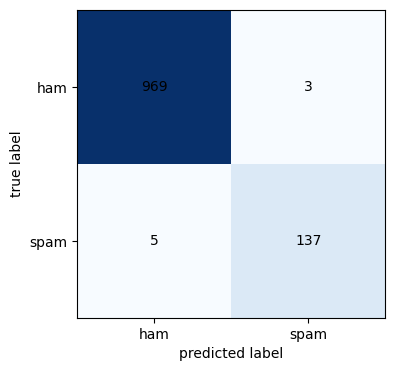

In [81]:
# Complete this cell.

nb_accuracy = (nb_test_pred == y_test).float().mean().item()
print(f"Naive Bayes test accuracy: {nb_accuracy:.3f}")

cm = compute_confusion_matrix(y_test, nb_test_pred)
plot_confusion_matrix(cm)

In [82]:
# Complete this cell.

log_odds = torch.log(theta_spam / theta_ham)
top_spam = torch.topk(log_odds, k=10).indices
top_ham = torch.topk(-log_odds, k=10).indices
print("spam words:", [vocabulary[i] for i in top_spam])
print("ham words:", [vocabulary[i] for i in top_ham])

spam words: ['claim', 'www', 'prize', '150p', 'co', '18', 'guaranteed', 'cs', '500', 'uk']
ham words: ['gt', 'lt', 'he', 'da', 'lor', 'ü', 'later', 'she', 'come', 'doing']


## 3.4 Threshold sweep

The default threshold for classifying a message as spam is 0.5. Use the validation set to inspect different thresholds and choose the threshold with the largest validation accuracy. Then apply that threshold once to the test set.

best validation threshold: 0.06
best validation accuracy:  0.986
test accuracy at tuned threshold: 0.994


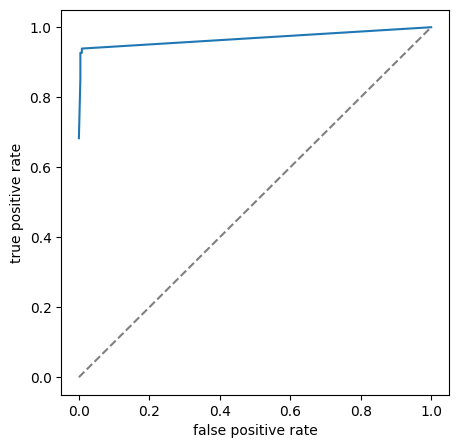

In [83]:
def threshold_curve(prob_spam, y_true, thresholds):
    y_true = y_true.reshape(-1)
    fpr_values = []
    tpr_values = []
    accuracy_values = []

    for threshold in thresholds:
        # Complete the implementation.
        pred = (prob_spam >= threshold).float()
        cm = compute_confusion_matrix(y_true, pred)
        tn, fp, fn, tp = cm.flatten()
        fpr_values.append(fp / (fp + tn))
        tpr_values.append(tp / (tp + fn))
        accuracy_values.append((tp + tn) / (tp + tn + fp + fn))
        

    return torch.stack(fpr_values), torch.stack(tpr_values), torch.stack(accuracy_values)


thresholds = torch.linspace(0.0, 1.0, 101)
nb_fpr, nb_tpr, nb_accuracy = threshold_curve(nb_val_prob_spam, y_val, thresholds)

best_idx = torch.argmax(nb_accuracy)
best_threshold = thresholds[best_idx]
print(f"best validation threshold: {best_threshold.item():.2f}")
print(f"best validation accuracy:  {nb_accuracy[best_idx].item():.3f}")

nb_test_pred_tuned = (nb_test_prob_spam >= best_threshold).float()
print(f"test accuracy at tuned threshold: {(nb_test_pred_tuned == y_test).float().mean().item():.3f}")

plt.figure(figsize=(5, 5))
plt.plot(nb_fpr, nb_tpr)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.show()

In [84]:
# My code to answer A3.4
# TODO: should we use the tuned threshold here?
pred = (nb_test_prob_spam >= 0.06 ).float()
compute_confusion_matrix(y_test, pred)

tensor([[969,   3],
        [  4, 138]])

---
# Assignment 4: A trainable PyTorch model
---
We now solve the same spam-classification task with a trainable PyTorch model. The model is a linear scoring rule followed by a sigmoid function. This is equivalent to logistic regression, but we write it as a `torch.nn.Module` to introduce the standard PyTorch model interface.

We use `BCELoss` because the labels are binary and the model output is a probability between 0 and 1.

## 4.1 Define the model

Complete the model below with one linear layer and one sigmoid activation.

In [85]:
class DetectSpamNetwork(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()
        # Complete the implementation.
        self.linear = torch.nn.Linear(num_features, 1)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Complete the implementation.
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

## 4.2 Train the model

The standard PyTorch training loop has five steps:

1. reset old gradients with `optimizer.zero_grad()`
2. compute predictions with `model(X)`
3. compute the loss
4. compute gradients with `loss.backward()`
5. update parameters with `optimizer.step()`

In [86]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in dataloader:
        # Complete the implementation.
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(X_batch)

    return total_loss / len(dataloader.dataset)


def evaluate(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0.0
    correct = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)

            pred_label = (pred >= 0.5).float()
            correct += (pred_label == y_batch).float().sum().item()
            total_loss += loss.item() * len(X_batch)

            predictions.append(pred_label.reshape(-1))
            targets.append(y_batch.reshape(-1))

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = correct / len(dataloader.dataset)
    return avg_loss, accuracy, torch.cat(predictions), torch.cat(targets)

In [87]:
torch.manual_seed(0)

model = DetectSpamNetwork(sms_dataset.num_features())
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

train_losses = []
validation_losses = []
validation_accuracies = []

for epoch in range(15):
    train_loss = train_one_epoch(train_loader, model, loss_fn, optimizer)
    validation_loss, validation_accuracy, _, _ = evaluate(validation_loader, model, loss_fn)

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)
    validation_accuracies.append(validation_accuracy)

    print(
        f"epoch {epoch + 1:02d}: "
        f"train loss={train_loss:.4f}, "
        f"validation loss={validation_loss:.4f}, "
        f"validation accuracy={validation_accuracy:.3f}"
    )

test_loss, test_accuracy, nn_pred, nn_target = evaluate(test_loader, model, loss_fn)
print(f"final test loss={test_loss:.4f}, final test accuracy={test_accuracy:.3f}")

epoch 01: train loss=0.3585, validation loss=0.2005, validation accuracy=0.937
epoch 02: train loss=0.1494, validation loss=0.1346, validation accuracy=0.968
epoch 03: train loss=0.1100, validation loss=0.1145, validation accuracy=0.973
epoch 04: train loss=0.0939, validation loss=0.1044, validation accuracy=0.973
epoch 05: train loss=0.0840, validation loss=0.0976, validation accuracy=0.975
epoch 06: train loss=0.0770, validation loss=0.0938, validation accuracy=0.977
epoch 07: train loss=0.0717, validation loss=0.0900, validation accuracy=0.978
epoch 08: train loss=0.0674, validation loss=0.0877, validation accuracy=0.978
epoch 09: train loss=0.0640, validation loss=0.0857, validation accuracy=0.978
epoch 10: train loss=0.0610, validation loss=0.0841, validation accuracy=0.978
epoch 11: train loss=0.0585, validation loss=0.0827, validation accuracy=0.978
epoch 12: train loss=0.0562, validation loss=0.0816, validation accuracy=0.978
epoch 13: train loss=0.0542, validation loss=0.0807,

## 4.3 Evaluate and interpret the trainable model

Plot the loss curves, inspect the confusion matrix, and compare the learned word weights to the Naive Bayes word scores.

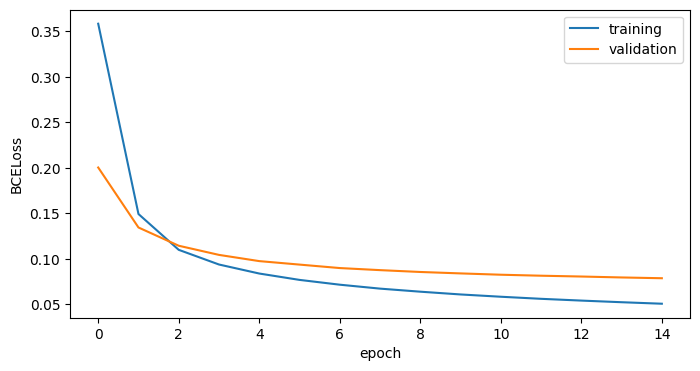

In [88]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="training")
plt.plot(validation_losses, label="validation")
plt.xlabel("epoch")
plt.ylabel("BCELoss")
plt.legend()
plt.show()

tensor([[969,   3],
        [ 13, 129]])


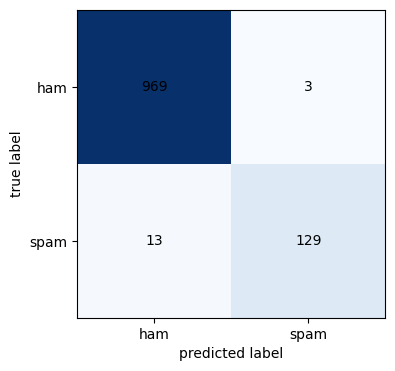

In [89]:
# Complete this cell.

cm = compute_confusion_matrix(nn_target, nn_pred)
print(cm)
plot_confusion_matrix(cm)

In [90]:
# Complete this cell.

weights = model.linear.weight.detach().reshape(-1)
top_spam = torch.topk(weights, k=10).indices
top_ham = torch.topk(-weights, k=10).indices
print("spam words:", [vocabulary[i] for i in top_spam])
print("ham words:", [vocabulary[i] for i in top_ham])

spam words: ['call', 'text', 'stop', 'txt', 'uk', 'reply', 'your', 'free', 'www', '1']
ham words: ['i', 'that', 'gt', 'lt', 'my', 'me', 'but', 'up', 'going', 'he']
